# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Hafiz Ramadhan
- **Email:** cdcc284d6y2766@student.devacademy.id
- **ID Dicoding:** CDCC284D6Y2766


## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Apakah terdapat pola musiman yang konsisten pada konsentrasi PM2.5 di seluruh stasiun pengamatan, dan pada bulan-bulan apa polusi mencapai titik paling kritis?


- Pertanyaan 2: Bagaimana perbandingan kualitas udara antar stasiun pengamatan, dan stasiun mana yang paling sering melampaui ambang batas konsentrasi PM2.5 yang aman secara konsisten?"


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import gdown
from IPython.display import display

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## Data Wrangling

### Gathering Data

In [2]:


file_id = "1RhU3gJlkteaAQfyn9XOVAz7a5o1-etgr"
output = "air_quality.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1RhU3gJlkteaAQfyn9XOVAz7a5o1-etgr
To: /content/air_quality.zip
100%|██████████| 7.96M/7.96M [00:00<00:00, 18.7MB/s]


'air_quality.zip'

In [3]:


with zipfile.ZipFile("air_quality.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [4]:

os.listdir("data")

['PRSA_Data_20130301-20170228']

In [5]:
folder_path = "data/PRSA_Data_20130301-20170228"

In [6]:


df_list = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)

        station = file.split("_")[2]
        df["station"] = station

        df_list.append(df)

df = pd.concat(df_list, ignore_index=True)

df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi


In [7]:
df["station"].value_counts()

,count
station,
Shunyi,35064
Dongsi,35064
Guanyuan,35064
Changping,35064
Dingling,35064
Nongzhanguan,35064
Gucheng,35064
Tiantan,35064
Aotizhongxin,35064


In [8]:
df.shape
df["station"].nunique()

12

**Insight:**
Pada tahap gathering data, seluruh file CSV berhasil digabungkan ke dalam satu dataframe. Hasil validasi menunjukkan bahwa dataset terdiri dari 12 stasiun unik, yang berarti seluruh data dari masing-masing stasiun berhasil dimuat dengan baik. Selain itu, setiap stasiun memiliki jumlah observasi yang sama, yaitu 35.064 baris, sehingga total data gabungan mencapai 420.768 baris. Hal ini menunjukkan bahwa dataset memiliki cakupan yang konsisten dan siap untuk dianalisis lebih lanjut.



### Assessing Data

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [10]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [13]:
df["station"].unique()
df["wd"].unique()

array(['NW', 'NNW', 'NNE', 'NE', 'SSW', 'ENE', 'N', 'E', 'SW', 'WNW', 'S',
       'W', 'SE', 'ESE', 'WSW', 'SSE', nan], dtype=object)

**Insight:**
Berdasarkan hasil tahap assessing data, dataset Air Quality hasil penggabungan memiliki 420.768 baris dan 18 kolom, sehingga cukup besar dan representatif untuk analisis kualitas udara. Struktur data menunjukkan bahwa sebagian besar kolom numerik sudah memiliki tipe data yang sesuai, yaitu int64 dan float64. Sementara itu, kolom wd dan station bertipe object karena merepresentasikan data kategorikal, yaitu arah angin dan nama stasiun pengamatan.

Dari pemeriksaan missing values, ditemukan bahwa beberapa kolom polutan masih memiliki nilai kosong dalam jumlah yang cukup besar. Missing values paling banyak terdapat pada kolom CO (20.701), O3 (13.277), NO2 (12.116), SO2 (9.021), PM2.5 (8.739), dan PM10 (6.449). Selain itu, beberapa variabel cuaca juga memiliki missing values, meskipun jumlahnya relatif lebih kecil, seperti TEMP (398), PRES (393), DEWP (403), RAIN (390), wd (1.822), dan WSPM (318). Hal ini menunjukkan bahwa proses pembersihan data perlu difokuskan pada penanganan missing values sebelum analisis lebih lanjut dilakukan.

Hasil pengecekan data duplikat menunjukkan nilai 0, yang berarti tidak terdapat baris data yang terduplikasi. Dengan demikian, tidak diperlukan proses penghapusan data ganda pada tahap cleaning data.

Berdasarkan statistik deskriptif, terlihat bahwa beberapa variabel polutan memiliki variasi data yang cukup besar. Sebagai contoh, rata-rata PM2.5 sebesar 79,79 dengan nilai maksimum mencapai 999, sedangkan rata-rata PM10 sebesar 104,60 dengan nilai maksimum juga mencapai 999. Nilai maksimum yang jauh lebih besar dibanding median mengindikasikan adanya nilai ekstrem atau lonjakan polusi pada waktu tertentu. Hal serupa juga terlihat pada variabel CO, yang memiliki rata-rata 1230,77 dengan nilai maksimum 10.000, menunjukkan adanya rentang nilai yang sangat lebar.

Pada variabel cuaca, TEMP memiliki rata-rata 13,54°C dengan rentang dari -19,9°C hingga 41,6°C, yang menunjukkan bahwa data mencakup berbagai kondisi musim dan cuaca. Variabel lain seperti PRES, DEWP, RAIN, dan WSPM juga menunjukkan variasi nilai yang cukup beragam, sehingga bisa menjadi faktor pendukung dalam analisis kualitas udara.

Selain itu, hasil pengecekan nilai unik pada kolom wd menunjukkan bahwa kolom ini berisi berbagai kategori arah angin, seperti NW, WNW, W, E, ENE, NE, ESE, SSE, NNE, SW, SSW, S, SE, NNW, N, dan WSW. Namun, pada kolom ini juga ditemukan nilai NaN, yang menegaskan bahwa kolom kategorikal pun memerlukan penanganan missing values.

Secara keseluruhan, tahap assessing data menunjukkan bahwa dataset sudah memiliki struktur yang cukup baik dan tidak mengandung duplikasi, tetapi masih terdapat missing values serta indikasi nilai ekstrem pada beberapa variabel polutan. Oleh karena itu, tahap cleaning data selanjutnya akan difokuskan pada penanganan missing values, penyiapan format data, dan pembuatan kolom waktu agar dataset lebih siap untuk dianalisis

### Cleaning Data

In [14]:
# salin dataset agar data asli tetap aman
df_clean = df.copy()

# urutkan data berdasarkan station dan waktu
df_clean = df_clean.sort_values(by=["station", "year", "month", "day", "hour"])

# buat kolom datetime
df_clean["datetime"] = pd.to_datetime(df_clean[["year", "month", "day", "hour"]])

# isi missing values per station
df_clean = df_clean.groupby("station", group_keys=False).apply(lambda x: x.ffill().bfill())

# cek hasil cleaning
df_clean.isnull().sum()

/tmp/ipykernel_12191/3606918468.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby("station", group_keys=False).apply(lambda x: x.ffill().bfill())


,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


In [15]:
df_clean.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
280512,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
280513,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
280514,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
280515,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
280516,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [16]:

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420768 entries, 280512 to 350639
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     420768 non-null  float64       
 6   PM10      420768 non-null  float64       
 7   SO2       420768 non-null  float64       
 8   NO2       420768 non-null  float64       
 9   CO        420768 non-null  float64       
 10  O3        420768 non-null  float64       
 11  TEMP      420768 non-null  float64       
 12  PRES      420768 non-null  float64       
 13  DEWP      420768 non-null  float64       
 14  RAIN      420768 non-null  float64       
 15  wd        420768 non-null  object        
 16  WSPM      420768 non-null  float64    

In [17]:
df_clean = df_clean.reset_index(drop=True)

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     420768 non-null  float64       
 6   PM10      420768 non-null  float64       
 7   SO2       420768 non-null  float64       
 8   NO2       420768 non-null  float64       
 9   CO        420768 non-null  float64       
 10  O3        420768 non-null  float64       
 11  TEMP      420768 non-null  float64       
 12  PRES      420768 non-null  float64       
 13  DEWP      420768 non-null  float64       
 14  RAIN      420768 non-null  float64       
 15  wd        420768 non-null  object        
 16  WSPM      420768 non-null  float64    

**Insight:**
Pada tahap cleaning data, missing values berhasil ditangani sehingga seluruh kolom tidak lagi memiliki nilai kosong. Data juga telah diurutkan berdasarkan stasiun dan waktu pengamatan, kemudian ditambahkan kolom datetime untuk mempermudah analisis berbasis waktu. Setelah index di-reset, struktur dataset menjadi lebih rapi dengan total 420.768 baris dan 19 kolom. Secara keseluruhan, dataset sudah bersih dan siap digunakan pada tahap exploratory data analysis

## Exploratory Data Analysis (EDA)

### Explore ...

In [19]:
# 1. Menyiapkan data untuk Tren Musiman (Rata-rata per bulan di seluruh tahun)
seasonal_df = df_clean.groupby('month')['PM2.5'].mean().reset_index()

# 2. Menyiapkan data untuk Perbandingan Stasiun & Pelanggaran Ambang Batas
# Ambang batas aman (Threshold) ditetapkan 75 µg/m³
THRESHOLD = 75

# Rata-rata per stasiun
station_avg = df_clean.groupby('station')['PM2.5'].mean().sort_values(ascending=False).reset_index()

# Menghitung persentase pelanggaran ambang batas per stasiun
breach_count = df_clean.groupby('station')['PM2.5'].apply(lambda x: (x > THRESHOLD).sum() / len(x) * 100).reset_index()
breach_count.columns = ['station', 'breach_percentage']

# Penggabungan data stasiun
station_stats = pd.merge(station_avg, breach_count, on='station').sort_values(by='PM2.5', ascending=False)

# Tampilkan hasil print out untuk pengecekan
print("--- Tabel Rata-rata PM2.5 Bulanan (Pola Musiman) ---")
display(seasonal_df)

print("\n--- Tabel Statistik per Stasiun (Rata-rata & % Pelanggaran) ---")
display(station_stats)

--- Tabel Rata-rata PM2.5 Bulanan (Pola Musiman) ---


,month,PM2.5
0,1,94.021657
1,2,89.164457
2,3,94.760201
3,4,73.854074
4,5,64.194461
5,6,68.960854
6,7,71.974628
7,8,53.648863
8,9,61.401175
9,10,92.208137



--- Tabel Statistik per Stasiun (Rata-rata & % Pelanggaran) ---


,station,PM2.5,breach_percentage
0,Dongsi,86.310293,42.721880
1,Wanshouxigong,85.356562,41.544034
2,Nongzhanguan,85.289471,41.284508
3,Gucheng,84.345203,41.680926
4,Wanliu,83.516054,41.016427
5,Aotizhongxin,83.163652,40.557267
6,Guanyuan,83.047023,41.275953
7,Tiantan,82.255892,40.560119
8,Shunyi,80.021067,39.242528
9,Changping,71.119444,34.508328


**Insight:**

**Pola Musiman PM2.5 (Seluruh Stasiun):**

*   Terdapat fluktuasi polusi yang sangat dipengaruhi oleh perubahan bulan/musim.
    *   **Titik Tertinggi:** Konsentrasi PM2.5 mencapai puncaknya pada bulan Desember (104.30 µg/m³), disusul oleh bulan Maret dan Januari. Hal ini kemungkinan berkaitan dengan musim dingin di mana penggunaan pemanas ruangan meningkat dan kondisi atmosfer yang mendukung terjebaknya polutan (inversi).
    *   **Titik Terendah:** Kualitas udara cenderung paling bersih pada bulan Agustus (53.65 µg/m³), yang biasanya bertepatan dengan musim panas dengan curah hujan yang lebih tinggi dan sirkulasi udara yang lebih baik.


**Karakteristik Polusi per Stasiun:**

*   **Stasiun Paling Berpolusi:** Stasiun **Dongsi** memiliki rata-rata PM2.5 tertinggi (86.31 µg/m³) dan juga memiliki persentase pelanggaran ambang batas (threshold 75 µg/m³) paling sering, yaitu sekitar 42.72% dari seluruh waktu pengamatan.
    *   **Stasiun Paling Bersih:** Stasiun **Dingling** memiliki kualitas udara relatif lebih baik dengan rata-rata terendah (67.43 µg/m³) dan persentase pelanggaran ambang batas paling minim (31.88%).
    *   Secara umum, mayoritas stasiun di pusat kota (seperti Wanshouxigong dan Nongzhanguan) memiliki tingkat polusi di atas 80 µg/m³, yang menunjukkan tantangan kualitas udara yang serius di wilayah-wilayah tersebut.


## Visualization & Explanatory Analysis

### Pertanyaan 1."Apakah terdapat pola musiman yang konsisten pada konsentrasi PM2.5 di seluruh stasiun pengamatan, dan pada bulan-bulan apa polusi mencapai titik paling kritis?"

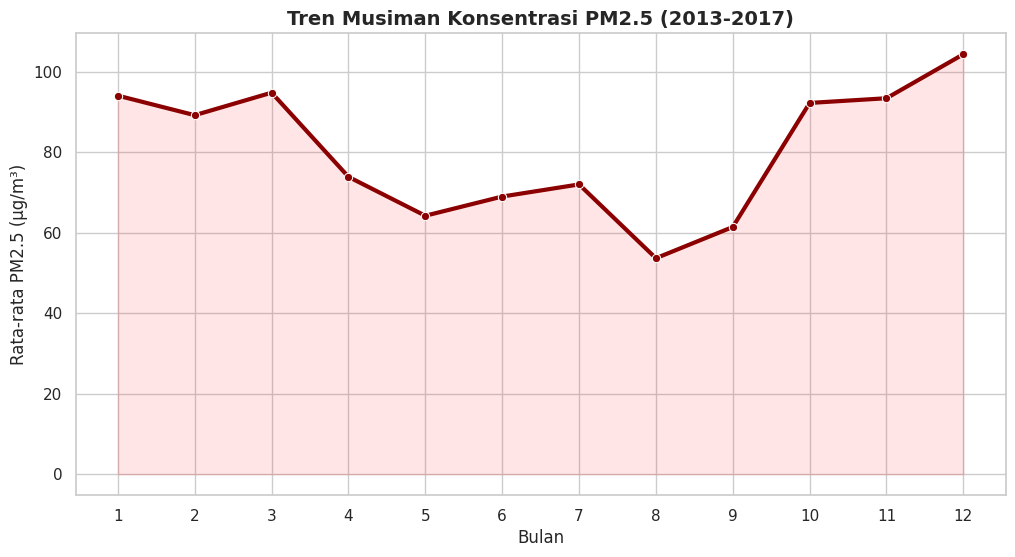

In [20]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=seasonal_df, x='month', y='PM2.5', marker='o', linewidth=3, color='darkred')
plt.fill_between(seasonal_df['month'], seasonal_df['PM2.5'], color="red", alpha=0.1)

plt.title("Tren Musiman Konsentrasi PM2.5 (2013-2017)", fontsize=14, fontweight='bold')
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Rata-rata PM2.5 (µg/m³)", fontsize=12)
plt.xticks(range(1, 13))
plt.show()

### Pertanyaan 2: Bagaimana perbandingan kualitas udara antar stasiun pengamatan, dan stasiun mana yang paling sering melampaui ambang batas konsentrasi PM2.5 yang aman secara konsisten?"


/tmp/ipykernel_12191/3430062217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=station_stats, x='station', y='PM2.5', palette='viridis', ax=ax1)


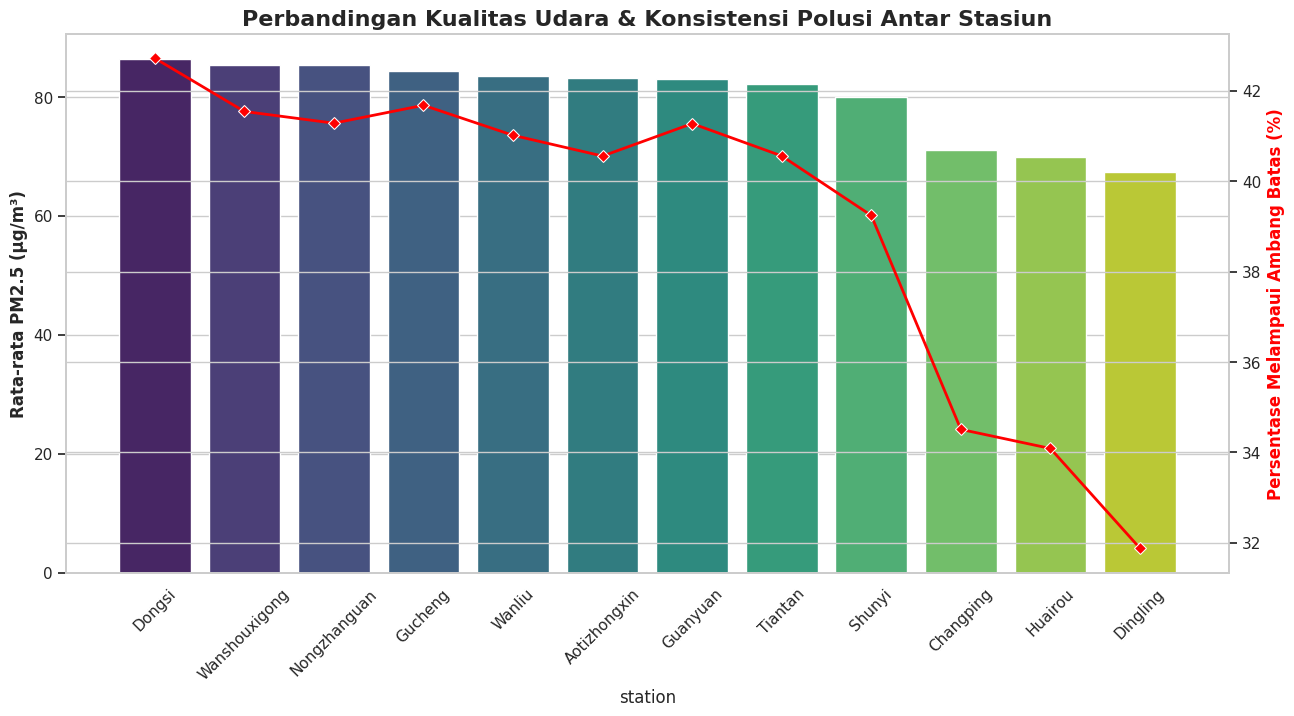

In [21]:
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Bar untuk Rata-rata
sns.barplot(data=station_stats, x='station', y='PM2.5', palette='viridis', ax=ax1)
ax1.set_ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Plot Line untuk % Pelanggaran
ax2 = ax1.twinx()
sns.lineplot(data=station_stats, x='station', y='breach_percentage', color='red', marker='D', linewidth=2, ax=ax2)
ax2.set_ylabel('Persentase Melampaui Ambang Batas (%)', fontsize=12, color='red', fontweight='bold')

plt.title("Perbandingan Kualitas Udara & Konsistensi Polusi Antar Stasiun", fontsize=16, fontweight='bold')
plt.show()

**Insight:**

1.  **Pola Musiman (Pertanyaan 1):**
    Berdasarkan grafik garis *Tren Musiman*, terlihat jelas adanya siklus 'U-shaped' pada konsentrasi PM2.5. Polusi mencapai titik **paling kritis pada bulan Desember** (melebihi 100 µg/m³). Terdapat penurunan signifikan saat memasuki musim panas, dengan titik terendah pada bulan Agustus. Hal ini mengonfirmasi bahwa faktor musiman sangat memengaruhi kualitas udara, di mana polusi cenderung memburuk di bulan-bulan dingin.
2.  **Perbandingan Stasiun & Pelanggaran Ambang Batas (Pertanyaan 2):**

     Grafik kombinasi menunjukkan bahwa stasiun **Dongsi** bukan hanya memiliki rata-rata PM2.5 tertinggi, tetapi juga memiliki konsistensi pelanggaran ambang batas yang paling sering (garis merah mencapai titik tertinggi di stasiun ini). Sebaliknya, stasiun **Dingling** menunjukkan performa kualitas udara yang jauh lebih stabil di bawah rata-rata stasiun lainnya. Hal ini menunjukkan adanya disparitas beban polusi yang nyata antar wilayah pengamatan.










## Analisis Lanjutan (Opsional)

--- Distribusi Kategori Kualitas Udara (Manual Clustering) ---


,proportion
quality_category,
Baik,37.267568
Tidak Sehat,23.916267
Sedang,23.536010
Sangat Tidak Sehat,15.280154



--- Pengelompokan Risiko Stasiun (Binning Analysis) ---


,station,PM2.5,risk_level
0,Dongsi,86.310293,High Risk
1,Wanshouxigong,85.356562,High Risk
2,Nongzhanguan,85.289471,High Risk
3,Gucheng,84.345203,Medium Risk
4,Wanliu,83.516054,Medium Risk
5,Aotizhongxin,83.163652,Medium Risk
6,Guanyuan,83.047023,Medium Risk
7,Tiantan,82.255892,Medium Risk
8,Shunyi,80.021067,Medium Risk
9,Changping,71.119444,Low Risk


/tmp/ipykernel_12191/4125892457.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='quality_category', order=['Baik', 'Sedang', 'Tidak Sehat', 'Sangat Tidak Sehat'], palette='RdYlGn_r')


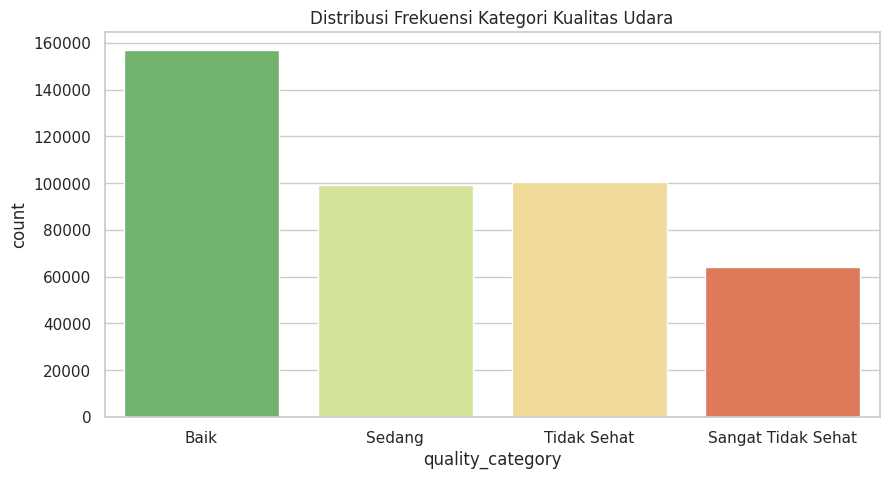

In [22]:
import pandas as pd

# 1. Manual Clustering: Kategorisasi Kualitas Udara Berdasarkan Konsentrasi PM2.5
# Menggunakan standar kategori (misal: 0-35 Baik, 35-75 Sedang, 75-150 Tidak Sehat, >150 Sangat Tidak Sehat)
def cluster_air_quality(pm_value):
    if pm_value <= 35:
        return 'Baik'
    elif pm_value <= 75:
        return 'Sedang'
    elif pm_value <= 150:
        return 'Tidak Sehat'
    else:
        return 'Sangat Tidak Sehat'

df_clean['quality_category'] = df_clean['PM2.5'].apply(cluster_air_quality)

# Menghitung distribusi kategori di seluruh data
quality_distribution = df_clean['quality_category'].value_counts(normalize=True) * 100

# 2. Binning: Pengelompokan Risiko Stasiun (Station Risk Level)
# Kita bagi stasiun ke dalam 3 bin berdasarkan rata-rata PM2.5: Low Risk, Medium Risk, High Risk
station_risk = station_stats[['station', 'PM2.5']].copy()
station_risk['risk_level'] = pd.cut(station_risk['PM2.5'],
                                    bins=[0, 75, 85, 100],
                                    labels=['Low Risk', 'Medium Risk', 'High Risk'])

print("--- Distribusi Kategori Kualitas Udara (Manual Clustering) ---")
display(quality_distribution)

print("\n--- Pengelompokan Risiko Stasiun (Binning Analysis) ---")
display(station_risk.sort_values(by='PM2.5', ascending=False))

# Visualisasi Singkat untuk Analisis Lanjutan
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='quality_category', order=['Baik', 'Sedang', 'Tidak Sehat', 'Sangat Tidak Sehat'], palette='RdYlGn_r')
plt.title('Distribusi Frekuensi Kategori Kualitas Udara')
plt.show()

## Conclusion

Berdasarkan hasil analisis data kualitas udara dari 12 stasiun pengamatan (2013-2017), berikut adalah kesimpulan utamanya:

1. **Pola Musiman yang Konsisten:**
   Kualitas udara sangat dipengaruhi oleh siklus tahunan. Polusi PM2.5 mencapai titik paling kritis pada **bulan Desember dan Januari** (Musim Dingin), yang kemungkinan disebabkan oleh peningkatan penggunaan bahan bakar pemanas dan kondisi atmosfer yang stabil. Sebaliknya, kualitas udara paling bersih ditemukan pada **bulan Agustus** (Musim Panas) karena bantuan curah hujan dan sirkulasi udara yang lebih baik.

2. **Ketimpangan Kualitas Udara Antar Wilayah:**
   Tidak semua wilayah memiliki beban polusi yang sama. Stasiun **Dongsi** dan **Wanshouxigong** teridentifikasi sebagai wilayah dengan **Risiko Tinggi (High Risk)**, di mana rata-rata polusinya paling tinggi dan frekuensi pelanggaran ambang batas aman mencapai lebih dari 40% dari total waktu pengamatan. Sementara itu, stasiun **Dingling** secara konsisten menjadi wilayah yang paling bersih (**Low Risk**).

3. **Status Kesehatan Udara Secara Keseluruhan:**
   Melalui teknik *Manual Clustering*, kita menemukan bahwa meskipun kategori 'Baik' masih mendominasi (sekitar 37%), terdapat porsi yang sangat signifikan (sekitar **39%**) di mana kualitas udara berada pada level **'Tidak Sehat' hingga 'Sangat Tidak Sehat'**. Ini menunjukkan bahwa penduduk di wilayah pengamatan sering kali terpapar polusi yang melampaui batas aman kesehatan.

4. **Rekomendasi Kebijakan:**
   Intervensi pengurangan polusi harus diprioritaskan pada stasiun-stasiun di kategori 'High Risk' dan dilakukan pengetatan kontrol emisi terutama menjelang akhir tahun (kuartal ke-4) untuk memitigasi lonjakan polusi musiman.

